In [8]:
import gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

np.bool8 = np.bool_

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


<h1> Double DQN

## Difference Between DQN and Double DQN

### DQN (Deep Q-Network)
In the traditional **DQN**, the update rule for the Q-value is as follows:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma \max_{a'} Q'(s', a') - Q(s, a) \right)
$$

Deep Q-learning is known to sometimes learn unrealistically high action values because it includes a maximization step over estimated action values, which tends to prefer overestimated to underestimated values. The problem of DQN or O learning is that the optimal policy of the Agent is always to choose the best action in any given state. The assumption behind the idea is that the best action has the maximum expected/estimated Q-value.However, the Agent knows nothing about the environment in the beginning, it needs to estimate $Q(s,a)$ at first and update them at each iteration. Such Q-values have lots of noises and we are never sure whether the action with maximum expected/estimated Q-value is really the best one.

### Double DQN
The idea of double Q-learning is to reduce overestimations by decomposing the max operation in the target into action selection and action evaluation.

**Double DQN** using two networks:
1. **Online network (Q)**: Used for selecting actions.
2. **Target network (Q')**: Used for evaluating the Q-value of the selected action.

In **Double DQN**, the update rule becomes:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left( r + \gamma Q'(s', \text{argmax}_{a'} Q(s', a')) - Q(s, a) \right)
$$

Where:
- The **online network** selects the next action: $$ a' = \text{argmax}_{a'} Q(s', a') $$
- The **target network** evaluates the Q-value for the selected action: $$ Q'(s', a') $$

This reduces overestimation by separating action selection from action evaluation.

---
Note: The difference between DQN with online offline network with Double DQN is how them update the Q-learning function. While traditional DQN update current q value by the maximum q value of the next state, Double DQN update the current q value by the next state q value correponding to the action have been choosen

In [10]:
class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(QNetwork, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, output_dim)
        )
    def forward(self, x):
        return self.layers(x)


In [11]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, s, a, r, s_, done):
        self.buffer.append((s, a, r, s_, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_, d = zip(*batch)
        return (np.array(s), np.array(a), np.array(r), np.array(s_), np.array(d))

    def __len__(self):
        return len(self.buffer)

In [12]:
class DoubleDQNAgent:
    def __init__(self, obs_dim, n_actions, gamma=0.99, lr=0.001, buffer_size=20000):
        self.obs_dim = obs_dim
        self.n_actions = n_actions
        self.gamma = gamma
        self.lr = lr

        self.model = QNetwork(obs_dim, n_actions).to(device)
        self.target_model = QNetwork(obs_dim, n_actions).to(device)
        self.target_model.load_state_dict(self.model.state_dict())
        self.target_model.eval()

        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()
        self.buffer = ReplayBuffer(buffer_size)

    def act(self, state, epsilon=0.05):
        if random.random() < epsilon:
            return random.randint(0, self.n_actions - 1)
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            q_values = self.model(state_tensor)
        return int(torch.argmax(q_values, dim=1).item())

    def remember(self, s, a, r, s_, done):
        self.buffer.push(s, a, r, s_, done)

    def train(self, batch_size=32):
        if len(self.buffer) < batch_size:
            return

        S, A, R, S_, D = self.buffer.sample(batch_size)
        S   = torch.FloatTensor(S).to(device)
        A   = torch.LongTensor(A).unsqueeze(1).to(device)
        R   = torch.FloatTensor(R).unsqueeze(1).to(device)
        S_  = torch.FloatTensor(S_).to(device)
        D   = torch.FloatTensor(D).unsqueeze(1).to(device)

        # Q(s,a)
        q_values = self.model(S).gather(1, A)

        # Double DQN: use model to select action, use target model to estimate value
        with torch.no_grad():
            next_actions = self.model(S_).argmax(1).unsqueeze(1)
            next_q = self.target_model(S_).gather(1, next_actions)
            q_targets = R + self.gamma * next_q * (1 - D)

        loss = self.loss_fn(q_values, q_targets)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target(self):
        self.target_model.load_state_dict(self.model.state_dict())

Episode 0, Score: -472.80, Avg(50): -472.80, Epsilon: 0.05
Episode 1, Score: -391.95, Avg(50): -432.38, Epsilon: 0.05
Episode 2, Score: -223.90, Avg(50): -362.89, Epsilon: 0.05
Episode 3, Score: -151.91, Avg(50): -310.14, Epsilon: 0.05
Episode 4, Score: -90.76, Avg(50): -266.27, Epsilon: 0.05
Episode 5, Score: -176.67, Avg(50): -251.33, Epsilon: 0.05
Episode 6, Score: -279.94, Avg(50): -255.42, Epsilon: 0.05
Episode 7, Score: -204.79, Avg(50): -249.09, Epsilon: 0.05
Episode 8, Score: -157.57, Avg(50): -238.92, Epsilon: 0.05
Episode 9, Score: -84.16, Avg(50): -223.45, Epsilon: 0.05
Episode 10, Score: -127.19, Avg(50): -214.70, Epsilon: 0.05
Episode 11, Score: -90.14, Avg(50): -204.32, Epsilon: 0.05
Episode 12, Score: -353.43, Avg(50): -215.79, Epsilon: 0.05
Episode 13, Score: -138.69, Avg(50): -210.28, Epsilon: 0.05
Episode 14, Score: -351.83, Avg(50): -219.72, Epsilon: 0.05
Episode 15, Score: -1.76, Avg(50): -206.09, Epsilon: 0.05
Episode 16, Score: -229.77, Avg(50): -207.49, Epsilon: 

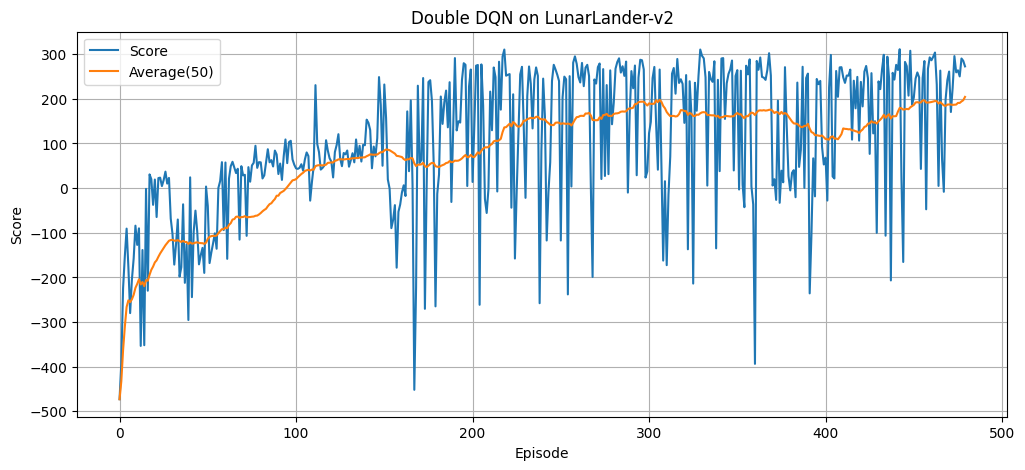

In [13]:
env = gym.make("LunarLander-v2")
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
agent = DoubleDQNAgent(obs_dim, n_actions)

episodes = 2000
max_t = 500
epsilon = 0.05
scores = []
avgs = []

time = 0
update_freq = 400

for episode in range(episodes):
    state, _ = env.reset()
    score = 0

    for t in range(max_t):
        time += 1
        action = agent.act(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.remember(state, action, reward, next_state, done)
        agent.train(batch_size=32)

        if time % update_freq == 0:
            agent.update_target()

        state = next_state
        score += reward
        if done:
            break

    scores.append(score)
    avg_score = np.mean(scores[-50:])
    avgs.append(avg_score)
    print(f"Episode {episode}, Score: {score:.2f}, Avg(50): {avg_score:.2f}, Epsilon: {epsilon:.2f}")
    if avg_score >= 200:
        print("Environment solved!")
        break

# Plot results
plt.figure(figsize=(12, 5))
plt.plot(scores, label='Score')
plt.plot(avgs, label='Average(50)')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('Double DQN on LunarLander-v2')
plt.legend()
plt.grid()
plt.show()